In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [97]:
x = np.linspace(-6, 6, 100)
x.shape

(100,)

In [98]:
y = np.sqrt(10**2-x**2)
y.shape

(100,)

In [99]:
y = np.hstack([y, -y])
x = np.hstack([x, -x])

In [100]:
x1 = np.linspace(-6, 6, 100)
y1 = np.sqrt(4**2-x1**2)
x1 = np.hstack([x1, -x1])
y1 = np.hstack([y1, -y1])

In [101]:
x1, y1

(array([-6.        , -5.87878788, -5.75757576, -5.63636364, -5.51515152,
        -5.39393939, -5.27272727, -5.15151515, -5.03030303, -4.90909091,
        -4.78787879, -4.66666667, -4.54545455, -4.42424242, -4.3030303 ,
        -4.18181818, -4.06060606, -3.93939394, -3.81818182, -3.6969697 ,
        -3.57575758, -3.45454545, -3.33333333, -3.21212121, -3.09090909,
        -2.96969697, -2.84848485, -2.72727273, -2.60606061, -2.48484848,
        -2.36363636, -2.24242424, -2.12121212, -2.        , -1.87878788,
        -1.75757576, -1.63636364, -1.51515152, -1.39393939, -1.27272727,
        -1.15151515, -1.03030303, -0.90909091, -0.78787879, -0.66666667,
        -0.54545455, -0.42424242, -0.3030303 , -0.18181818, -0.06060606,
         0.06060606,  0.18181818,  0.3030303 ,  0.42424242,  0.54545455,
         0.66666667,  0.78787879,  0.90909091,  1.03030303,  1.15151515,
         1.27272727,  1.39393939,  1.51515152,  1.63636364,  1.75757576,
         1.87878788,  2.        ,  2.12121212,  2.2

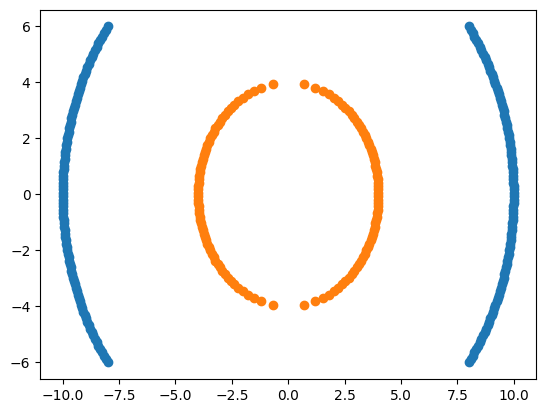

In [102]:
plt.scatter(y,x)
plt.scatter(y1, x1)

In [103]:
df1 = pd.DataFrame(np.vstack([y,x]).T, columns=["X1", "X2"])
df1["Y"] = 0

df2 = pd.DataFrame(np.vstack([y1,x1]).T, columns=["X1", "X2"])
df2["Y"] = 1

In [104]:
df1

,X1,X2,Y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0
...,...,...,...
195,-8.341649,-5.515152,0
196,-8.260230,-5.636364,0
197,-8.176205,-5.757576,0
198,-8.089490,-5.878788,0


In [105]:
df2

,X1,X2,Y
0,NaN,-6.000000,1
1,NaN,-5.878788,1
2,NaN,-5.757576,1
3,NaN,-5.636364,1
4,NaN,-5.515152,1
...,...,...,...
195,NaN,-5.515152,1
196,NaN,-5.636364,1
197,NaN,-5.757576,1
198,NaN,-5.878788,1


In [106]:
df = pd.concat([df1, df2], ignore_index = True)
df.head()

,X1,X2,Y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0


In [107]:
df.sample()

,X1,X2,Y
159,-9.933479,-1.151515,0


In [108]:
df1 = df.copy()

In [109]:
df1['X1square'] = df1['X1']**2
df1['X2square'] = df1['X2']**2
df1['X1X2'] = df1['X1'] * df1['X2']
df1.head()

,X1,X2,Y,X1square,X2square,X1X2
0,8.000000,-6.000000,0,64.000000,36.000000,-48.000000
1,8.089490,-5.878788,0,65.439853,34.560147,-47.556397
2,8.176205,-5.757576,0,66.850321,33.149679,-47.075117
3,8.260230,-5.636364,0,68.231405,31.768595,-46.557662
4,8.341649,-5.515152,0,69.583104,30.416896,-46.005457


In [110]:
df1=df1.dropna()

In [111]:
X = df1[["X1square", "X2square", "X1X2"]]
y = df1["Y"]

In [112]:
X

,X1square,X2square,X1X2
0,64.000000,36.000000,-48.000000
1,65.439853,34.560147,-47.556397
2,66.850321,33.149679,-47.075117
3,68.231405,31.768595,-46.557662
4,69.583104,30.416896,-46.005457
...,...,...,...
378,4.066116,11.933884,6.965957
379,3.213958,12.786042,6.410445
380,2.332415,13.667585,5.646103
381,1.421488,14.578512,4.552271


In [113]:
y

,Y
0,0
1,0
2,0
3,0
4,0
...,...
378,1
379,1
380,1
381,1


In [114]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state= 1)

In [115]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((232, 3), (100, 3), (232,), (100,))

In [116]:
!pip install plotly

In [117]:
import plotly.express as px
fig = px.scatter_3d(df1, x = 'X1square', y= 'X2square', z= 'X1X2', color= "Y")
fig.show()

In [118]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
clf = SVC(kernel= 'linear')   #why linear? >> we have created polynomial
clf

SVC(kernel='linear')

In [119]:
clf.fit(X_train, y_train)

SVC(kernel='linear')

In [120]:
y_pred = clf.predict(X_test)

In [121]:
accuracy_score(y_test, y_pred)

1.0

In [122]:
#till now we have done manually
#we will use svc kernel's

In [123]:
df = df.dropna()

In [124]:
df.head()

,X1,X2,Y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0


In [125]:
X = df[['X1', 'X2']]
y = df['Y']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.3, random_state= 1)

In [127]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
clf = SVC(kernel= 'poly')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.62

In [128]:
#poly kernel didnt perform well, so we used rbf

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = "rbf")
cls.fit(X_train, y_train)
y_pred = cls.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [129]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
cls = SVC(kernel = "sigmoid")
cls.fit(X_train, y_train)
y_pred = cls.predict(X_test)
accuracy_score(y_test, y_pred)

0.65

In [130]:
#internal homework>> try to do kernel hyperparameter tuning using grid search cv

In [134]:
params = {
    'C': [1,2,3,4,10,15,100,200],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': [0.01,0.2,0.1,0.3]
}

In [135]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(SVC(), param_grid = params, cv= 5, verbose= 3)
grid

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 2, 3, 4, 10, 15, 100, 200],
                         'gamma': [0.01, 0.2, 0.1, 0.3],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             verbose=3)

In [136]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
[CV 1/5] END ....C=1, gamma=0.01, kernel=linear;, score=0.596 total time=   0.0s
[CV 2/5] END ....C=1, gamma=0.01, kernel=linear;, score=0.596 total time=   0.0s
[CV 3/5] END ....C=1, gamma=0.01, kernel=linear;, score=0.587 total time=   0.0s
[CV 4/5] END ....C=1, gamma=0.01, kernel=linear;, score=0.587 total time=   0.0s
[CV 5/5] END ....C=1, gamma=0.01, kernel=linear;, score=0.609 total time=   0.0s
[CV 1/5] END .......C=1, gamma=0.01, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END .......C=1, gamma=0.01, kernel=rbf;, score=1.000 total time=   0.0s
[CV 3/5] END .......C=1, gamma=0.01, kernel=rbf;, score=1.000 total time=   0.0s
[CV 4/5] END .......C=1, gamma=0.01, kernel=rbf;, score=1.000 total time=   0.0s
[CV 5/5] END .......C=1, gamma=0.01, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/5] END ......C=1, gamma=0.01, kernel=poly;, score=0.596 total time=   0.0s
[CV 2/5] END ......C=1, gamma=0.01, kernel=pol

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 2, 3, 4, 10, 15, 100, 200],
                         'gamma': [0.01, 0.2, 0.1, 0.3],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             verbose=3)

In [137]:
grid.best_score_

np.float64(1.0)

In [139]:
grid.best_estimator_

SVC(C=1, gamma=0.01)

In [140]:
grid.best_score_

np.float64(1.0)

In [141]:
grid.best_index_

np.int64(1)